In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

data_cols = ['Bet','CashedOut', 'Bonus', 'Profit', 'BustedAt']

#helper function to mke 
def rainbow(data, n=None, mode=None): 
    if n is not None and mode=='sample': 
        d = data.sample(n)
    elif n is not None and mode=='head':
        d = data.head(n)
    else:
        d = data
    cols = d.columns
    palette = sns.color_palette('pastel', len(cols)).as_hex()

    #formatting by ading commas and decimal places to the columns about money
    styles = d.style.format('{:,.2f}', subset=data_cols)

    #coloring each rows text 
    for col, color in zip(cols, palette):
        styles = styles.set_properties(subset=[col],**{'background-color': 'black', 'color': color})
    return styles

sns.set_theme(style='whitegrid')

df = pd.read_csv('Data/bustabit.csv', parse_dates=['PlayDate'])
df['Won'] = df['CashedOut'].notna()   # missing CashedOut = player busted (lost)
print(f"{len(df)} bets from {df['Username'].nunique()} players")
rainbow(df.drop(columns=['Id', 'GameID']).describe())

50000 bets from 4149 players


,Bet,CashedOut,Bonus,Profit,BustedAt
count,"50,000.00","28,734.00","28,734.00","28,734.00","50,000.00"
mean,"2,935.25",1.69,1.38,"1,534.77",16.79
std,"30,651.93",2.19,1.63,"20,000.82","1,172.88"
min,1.00,1.00,0.00,0.00,0.00
25%,4.00,1.07,0.00,0.85,1.31
50%,20.00,1.21,1.00,5.33,1.95
75%,180.00,1.57,2.47,63.03,3.85
max,"1,000,000.00",126.00,12.14,"1,175,993.10","251,025.13"


In [8]:
rainbow(df, 20, 'sample') #Random 20 different rows

,Id,GameID,Username,Bet,CashedOut,Bonus,Profit,BustedAt,PlayDate,Won
31587,15809168,3375912,xrnath,172.00,1.04,0.00,6.88,1.66,2016-11-23 15:13:57+00:00,True
15981,8058829,3331192,NEONDOUGH,"11,250.00",1.01,0.00,112.50,26.40,2016-11-10 23:37:33+00:00,True
7611,6676965,3325319,benjovis,2.00,1.04,0.00,0.08,4.94,2016-11-09 07:49:23+00:00,True
37267,12394731,3354303,simas,1.00,nan,nan,nan,2.75,2016-11-17 12:43:51+00:00,False
36024,23957243,3419347,mafiaidol,"35,000.00",1.50,2.78,"18,472.39",2.08,2016-12-05 23:39:58+00:00,True
43369,9033569,3335305,Profitz,111.00,nan,nan,nan,1.35,2016-11-12 04:06:57+00:00,False
27008,21532135,3407045,Dougpuocl,2.00,nan,nan,nan,4.84,2016-12-02 11:08:42+00:00,False
46344,25377646,3427089,Jr5uclezFwvDFV5,41.00,nan,nan,nan,1.78,2016-12-08 03:41:01+00:00,False
660,17135191,3383638,benzenhen,"3,000.00",nan,nan,nan,7.41,2016-11-25 19:28:27+00:00,False
43147,21188517,3405271,ugneri,85.00,1.33,0.00,28.05,4.25,2016-12-01 23:08:22+00:00,True


In [9]:
rainbow(df, 20, 'head')

,Id,GameID,Username,Bet,CashedOut,Bonus,Profit,BustedAt,PlayDate,Won
0,14196549,3366002,papai,5.00,1.20,0.00,1.00,8.24,2016-11-20 19:44:19+00:00,True
1,10676217,3343882,znay22,3.00,nan,nan,nan,1.40,2016-11-14 14:21:50+00:00,False
2,15577107,3374646,rrrrrrrr,4.00,1.33,3.00,1.44,3.15,2016-11-23 06:39:15+00:00,True
3,25732127,3429241,sanya1206,10.00,nan,nan,nan,1.63,2016-12-08 18:13:55+00:00,False
4,17995432,3389174,ADM,50.00,1.50,1.40,25.70,2.29,2016-11-27 08:14:48+00:00,True
5,14147823,3365723,afrod,2.00,nan,nan,nan,1.04,2016-11-20 17:50:55+00:00,False
6,10802671,3344556,charles150,1.00,1.05,4.00,0.09,1.05,2016-11-14 18:52:58+00:00,True
7,6155532,3323151,antaresgold,8.00,nan,nan,nan,1.13,2016-11-08 16:57:04+00:00,False
8,15421788,3373736,fluxxy,"2,000.00",1.20,0.00,400.00,9.14,2016-11-23 00:26:05+00:00,True
9,3387542,3311658,jim4beaver,"1,000.00",1.05,0.00,50.00,10.09,2016-11-05 10:32:34+00:00,True


Organize the data to sort by each player's previous play date and gambling behaviors.

In [10]:
df.sort_values(['Username', 'PlayDate']).reset_index(drop=True) #track the players' behavior throughout each day they played. 
#created these to keep track of past times they bet and won
df['PrevBet'] = df.groupby('Username')['Bet'].shift(1)
df['PrevWon'] = df.groupby('Username')['Won'].shift(1)
# Is this bet bigger then the last one they did?
df['BetIncreased'] = df['Bet'] > df['PrevBet']
seq_df = df.dropna(subset=['PrevWon', 'PrevBet']).copy() #no need to keep the first ever time user betted since there are no history before
seq_df['PrevOutcome'] = seq_df['PrevWon'].map({True: 'After Win', False: 'After Loss'})

print(f"There are {len(seq_df):,} sequential bet that exhibit loss chasing like behaviors")

There are 45,851 sequential bet that exhibit loss chasing like behaviors


Bar chart showing loss chassing behaviors

/tmp/ipykernel_1039/3206553785.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=prop_df, x='PrevOutcome', y='Percentage', palette=['#8a4f7d', '#88a096'], order=['After Loss', 'After Win'])


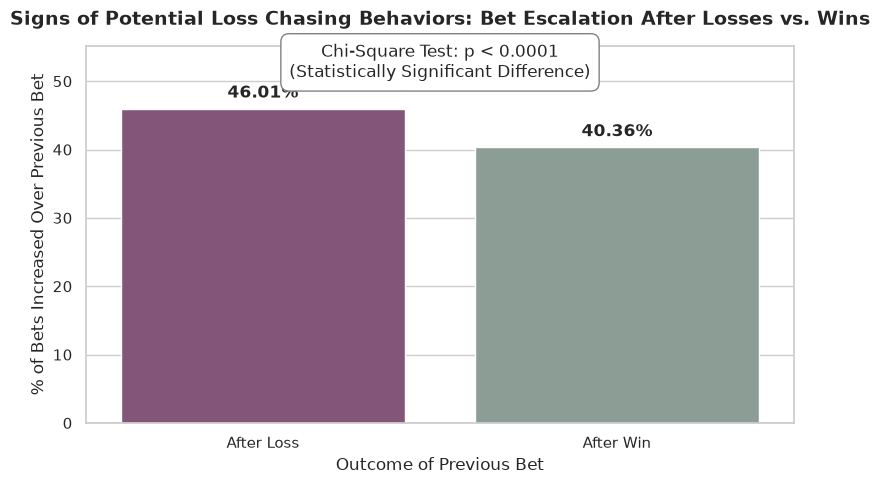

Chi-Square Statistic: 145.95 | P-Value: 1.3281e-33


In [15]:
#table that counts the bet as they increase and bet previous outcome
Betting_Vs_Outcome_table = pd.crosstab(seq_df['PrevOutcome'], seq_df['BetIncreased'])
chi2, p_val, dof, expected = stats.chi2_contingency(Betting_Vs_Outcome_table)
prop_df = seq_df.groupby('PrevOutcome')['BetIncreased'].mean().reset_index()
prop_df['Percentage'] = prop_df['BetIncreased'] * 100
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=prop_df, x='PrevOutcome', y='Percentage', palette=['#8a4f7d', '#88a096'], order=['After Loss', 'After Win'])

plt.title('Signs of Potential Loss Chasing Behaviors: Bet Escalation After Losses vs. Wins', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('% of Bets Increased Over Previous Bet', fontsize=12)
plt.xlabel('Outcome of Previous Bet', fontsize=12)
plt.ylim(0, max(prop_df['Percentage']) * 1.2)

# Annotate percentages on bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5), textcoords='offset points')

# Annotate Chi-Square p-value directly on the chart
p_text = f"p < 0.0001" if p_val < 0.0001 else f"p = {p_val:.4f}"
plt.text(0.5, max(prop_df['Percentage']) * 1.1, f"Chi-Square Test: {p_text}\n(Statistically Significant Difference)", 
         ha='center', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray'))

plt.tight_layout()
plt.show()

print(f"Chi-Square Statistic: {chi2:.2f} | P-Value: {p_val:.4e}")

Histogram of the players bet sizing 

In [ ]:
plt.figure(figsize=10, 6)